In [21]:
#Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [22]:
df_DA_Belgium = df[(df['job_country'] == 'Belgium') & (df['job_title'] == 'Data Analyst')].copy()

In [23]:
df_DA_Belgium['job_posted_month_no'] = df_DA_Belgium['job_posted_date'].dt.month

In [24]:
df_DA_Belgium_explode = df_DA_Belgium.explode('job_skills')

In [25]:
df_DA_Belgium_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

job_skills,airflow,alteryx,assembly,aws,azure,bigquery,c,c#,cassandra,chef,...,t-sql,tableau,tensorflow,unify,vba,visio,visual basic,vue,windows,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,12,0,2,0,0,0,...,4,19,0,0,2,0,0,1,0,5
2,0,0,0,1,11,0,1,0,0,0,...,0,16,0,0,2,0,0,1,0,2
3,0,1,0,2,13,2,1,0,0,0,...,1,17,0,0,2,0,0,0,0,0
4,0,1,0,3,17,1,1,0,0,0,...,2,22,0,0,3,0,0,3,0,3
5,0,1,0,0,3,1,0,0,0,0,...,0,9,0,1,3,0,0,2,0,1
6,0,0,1,2,14,0,0,2,0,0,...,0,9,1,0,1,0,0,5,0,1
7,0,0,0,0,4,0,0,2,0,0,...,0,9,0,0,1,0,0,2,1,4
8,0,0,0,0,14,0,0,2,0,0,...,2,19,2,0,1,0,1,2,0,4
9,0,0,0,6,12,0,0,0,0,0,...,0,5,0,0,1,0,0,5,0,1


In [26]:
df_DA_Belgium_pivot = df_DA_Belgium_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_Belgium_pivot.loc['Total'] = df_DA_Belgium_pivot.sum()

df_DA_Belgium_pivot[df_DA_Belgium_pivot.loc['Total'].sort_values(ascending=False).index]

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,42,32,27,25,30,19,19,12,8,2,...,1,0,0,0,0,0,0,0,0,0
2,28,15,12,7,22,16,9,11,6,4,...,0,0,0,0,0,0,0,0,0,0
3,40,32,20,15,34,17,22,13,8,8,...,0,0,0,0,0,0,0,0,0,0
4,59,39,29,27,16,22,18,17,12,12,...,0,0,0,0,0,1,0,0,0,0
5,24,17,14,22,16,9,13,3,7,7,...,0,1,0,1,0,0,0,1,0,0
6,43,28,26,30,22,9,12,14,8,5,...,0,0,1,0,0,0,0,0,0,0
7,22,12,20,20,12,9,8,4,2,1,...,0,0,0,0,0,0,0,0,0,1
8,47,37,38,23,16,19,11,14,17,8,...,0,0,0,0,0,0,0,0,1,0
9,21,10,12,16,16,5,6,12,8,6,...,0,0,0,0,0,0,0,0,0,0


In [27]:
df_DA_Belgium_pivot.loc['Total'].sort_values(ascending=False)

job_skills
sql             413
python          274
power bi        250
excel           230
sas             222
               ... 
sheets            1
visio             1
unify             1
visual basic      1
windows           1
Name: Total, Length: 86, dtype: int64

In [28]:
df_DA_Belgium_pivot = df_DA_Belgium_pivot[df_DA_Belgium_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_Belgium_pivot = df_DA_Belgium_pivot.drop('Total')

df_DA_Belgium_pivot

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,42,32,27,25,30,19,19,12,8,2,...,1,0,0,0,0,0,0,0,0,0
2,28,15,12,7,22,16,9,11,6,4,...,0,0,0,0,0,0,0,0,0,0
3,40,32,20,15,34,17,22,13,8,8,...,0,0,0,0,0,0,0,0,0,0
4,59,39,29,27,16,22,18,17,12,12,...,0,0,0,0,0,1,0,0,0,0
5,24,17,14,22,16,9,13,3,7,7,...,0,1,0,1,0,0,0,1,0,0
6,43,28,26,30,22,9,12,14,8,5,...,0,0,1,0,0,0,0,0,0,0
7,22,12,20,20,12,9,8,4,2,1,...,0,0,0,0,0,0,0,0,0,1
8,47,37,38,23,16,19,11,14,17,8,...,0,0,0,0,0,0,0,0,1,0
9,21,10,12,16,16,5,6,12,8,6,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

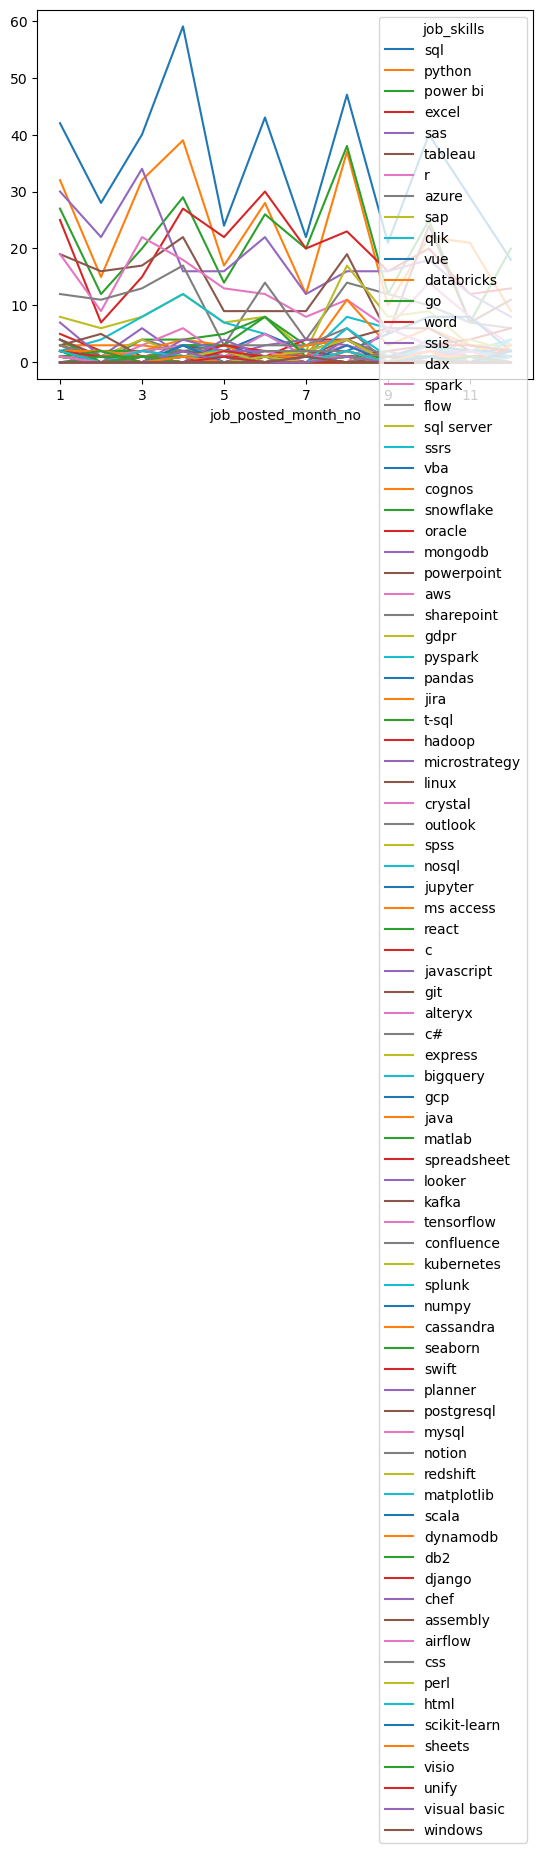

In [29]:
df_DA_Belgium_pivot.plot(kind='line')

In [30]:
df_DA_Belgium.groupby('job_posted_month_no').size()

job_posted_month_no
1     90
2     47
3     72
4     96
5     57
6     73
7     56
8     95
9     60
10    77
11    47
12    39
dtype: int64

In [35]:
DA_Totals = df_DA_Belgium.groupby('job_posted_month_no').size()

df_DA_Belgium_pivot

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,42,32,27,25,30,19,19,12,8,2,...,1,0,0,0,0,0,0,0,0,0
2,28,15,12,7,22,16,9,11,6,4,...,0,0,0,0,0,0,0,0,0,0
3,40,32,20,15,34,17,22,13,8,8,...,0,0,0,0,0,0,0,0,0,0
4,59,39,29,27,16,22,18,17,12,12,...,0,0,0,0,0,1,0,0,0,0
5,24,17,14,22,16,9,13,3,7,7,...,0,1,0,1,0,0,0,1,0,0
6,43,28,26,30,22,9,12,14,8,5,...,0,0,1,0,0,0,0,0,0,0
7,22,12,20,20,12,9,8,4,2,1,...,0,0,0,0,0,0,0,0,0,1
8,47,37,38,23,16,19,11,14,17,8,...,0,0,0,0,0,0,0,0,1,0
9,21,10,12,16,16,5,6,12,8,6,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_DA_Belgium_pivot.div(DA_Totals/100, axis=0)  #axis is 0 since we work on rows/index

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,46.666667,35.555556,30.000000,27.777778,33.333333,21.111111,21.111111,13.333333,8.888889,2.222222,...,1.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,59.574468,31.914894,25.531915,14.893617,46.808511,34.042553,19.148936,23.404255,12.765957,8.510638,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
3,55.555556,44.444444,27.777778,20.833333,47.222222,23.611111,30.555556,18.055556,11.111111,11.111111,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,61.458333,40.625000,30.208333,28.125000,16.666667,22.916667,18.750000,17.708333,12.500000,12.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.041667,0.00000,0.000000,0.000000,0.000000
5,42.105263,29.824561,24.561404,38.596491,28.070175,15.789474,22.807018,5.263158,12.280702,12.280702,...,0.000000,1.754386,0.000000,1.754386,0.000000,0.000000,0.00000,1.754386,0.000000,0.000000
6,58.904110,38.356164,35.616438,41.095890,30.136986,12.328767,16.438356,19.178082,10.958904,6.849315,...,0.000000,0.000000,1.369863,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
7,39.285714,21.428571,35.714286,35.714286,21.428571,16.071429,14.285714,7.142857,3.571429,1.785714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.785714
8,49.473684,38.947368,40.000000,24.210526,16.842105,20.000000,11.578947,14.736842,17.894737,8.421053,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.052632,0.000000
9,35.000000,16.666667,20.000000,26.666667,26.666667,8.333333,10.000000,20.000000,13.333333,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [39]:
df_DA_Belgium_percent = df_DA_Belgium_pivot.div(DA_Totals/100, axis=0)

df_DA_Belgium_percent

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,46.666667,35.555556,30.000000,27.777778,33.333333,21.111111,21.111111,13.333333,8.888889,2.222222,...,1.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,59.574468,31.914894,25.531915,14.893617,46.808511,34.042553,19.148936,23.404255,12.765957,8.510638,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
3,55.555556,44.444444,27.777778,20.833333,47.222222,23.611111,30.555556,18.055556,11.111111,11.111111,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,61.458333,40.625000,30.208333,28.125000,16.666667,22.916667,18.750000,17.708333,12.500000,12.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.041667,0.00000,0.000000,0.000000,0.000000
5,42.105263,29.824561,24.561404,38.596491,28.070175,15.789474,22.807018,5.263158,12.280702,12.280702,...,0.000000,1.754386,0.000000,1.754386,0.000000,0.000000,0.00000,1.754386,0.000000,0.000000
6,58.904110,38.356164,35.616438,41.095890,30.136986,12.328767,16.438356,19.178082,10.958904,6.849315,...,0.000000,0.000000,1.369863,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
7,39.285714,21.428571,35.714286,35.714286,21.428571,16.071429,14.285714,7.142857,3.571429,1.785714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.785714
8,49.473684,38.947368,40.000000,24.210526,16.842105,20.000000,11.578947,14.736842,17.894737,8.421053,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.052632,0.000000
9,35.000000,16.666667,20.000000,26.666667,26.666667,8.333333,10.000000,20.000000,13.333333,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [ ]:
df_DA_Belgium_percent = df_DA_Belgium_percent.reset_index()
df_DA_Belgium_percent['job_posted_month'] = df_DA_Belgium_percent['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_Belgium_percent = df_DA_Belgium_percent.set_index('job_posted_month')
df_DA_Belgium_percent = df_DA_Belgium_percent.drop(columns='job_posted_month_no')

df_DA_Belgium_percent

job_skills,sql,python,power bi,excel,sas,tableau,r,azure,sap,qlik,...,airflow,css,perl,html,scikit-learn,sheets,visio,unify,visual basic,windows
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,46.666667,35.555556,30.000000,27.777778,33.333333,21.111111,21.111111,13.333333,8.888889,2.222222,...,1.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
Feb,59.574468,31.914894,25.531915,14.893617,46.808511,34.042553,19.148936,23.404255,12.765957,8.510638,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
Mar,55.555556,44.444444,27.777778,20.833333,47.222222,23.611111,30.555556,18.055556,11.111111,11.111111,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
Apr,61.458333,40.625000,30.208333,28.125000,16.666667,22.916667,18.750000,17.708333,12.500000,12.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.041667,0.00000,0.000000,0.000000,0.000000
May,42.105263,29.824561,24.561404,38.596491,28.070175,15.789474,22.807018,5.263158,12.280702,12.280702,...,0.000000,1.754386,0.000000,1.754386,0.000000,0.000000,0.00000,1.754386,0.000000,0.000000
Jun,58.904110,38.356164,35.616438,41.095890,30.136986,12.328767,16.438356,19.178082,10.958904,6.849315,...,0.000000,0.000000,1.369863,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
Jul,39.285714,21.428571,35.714286,35.714286,21.428571,16.071429,14.285714,7.142857,3.571429,1.785714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.785714
Aug,49.473684,38.947368,40.000000,24.210526,16.842105,20.000000,11.578947,14.736842,17.894737,8.421053,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.052632,0.000000
Sep,35.000000,16.666667,20.000000,26.666667,26.666667,8.333333,10.000000,20.000000,13.333333,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [41]:
df_DA_Belgium_percent.iloc[:, :5]

job_skills,sql,python,power bi,excel,sas
job_posted_month,,,,,
Jan,46.666667,35.555556,30.000000,27.777778,33.333333
Feb,59.574468,31.914894,25.531915,14.893617,46.808511
Mar,55.555556,44.444444,27.777778,20.833333,47.222222
Apr,61.458333,40.625000,30.208333,28.125000,16.666667
May,42.105263,29.824561,24.561404,38.596491,28.070175
Jun,58.904110,38.356164,35.616438,41.095890,30.136986
Jul,39.285714,21.428571,35.714286,35.714286,21.428571
Aug,49.473684,38.947368,40.000000,24.210526,16.842105
Sep,35.000000,16.666667,20.000000,26.666667,26.666667


<Axes: xlabel='job_posted_month'>

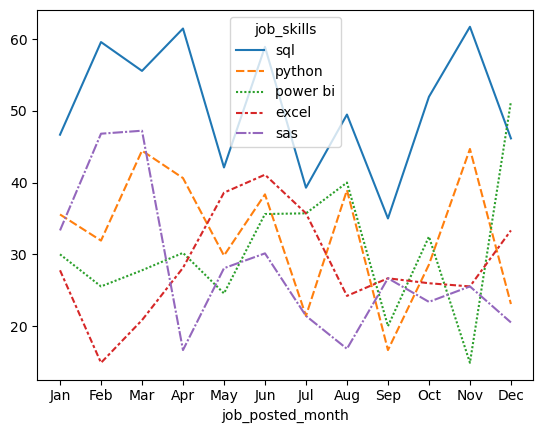

In [42]:
df_plot = df_DA_Belgium_percent.iloc[:, :5]

sns.lineplot(data=df_plot)

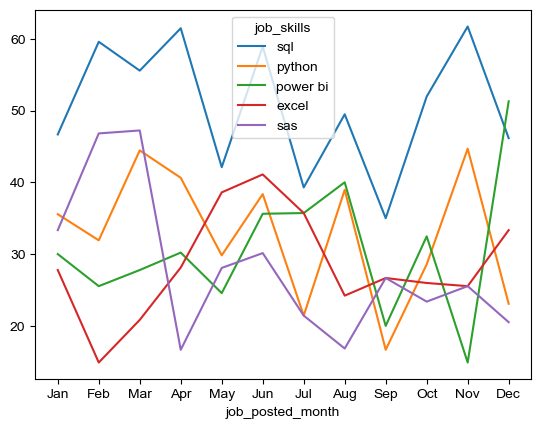

In [43]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')

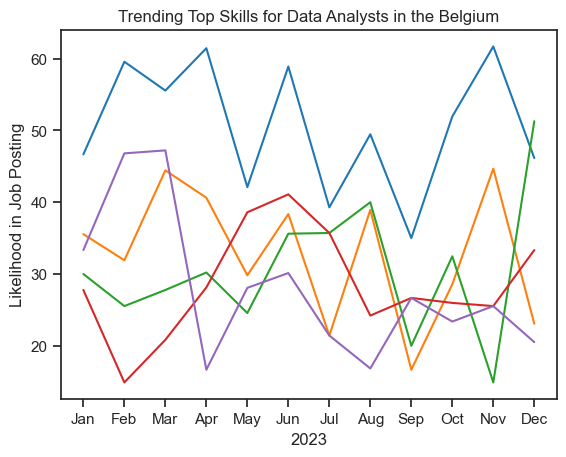

In [44]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')

plt.title('Trending Top Skills for Data Analysts in the Belgium')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

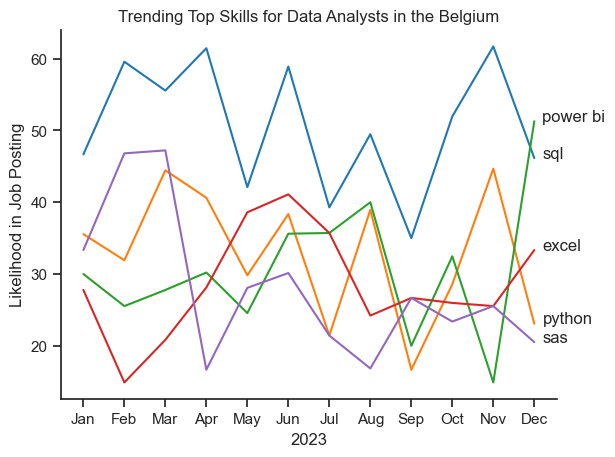

In [48]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Trending Top Skills for Data Analysts in the Belgium')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])

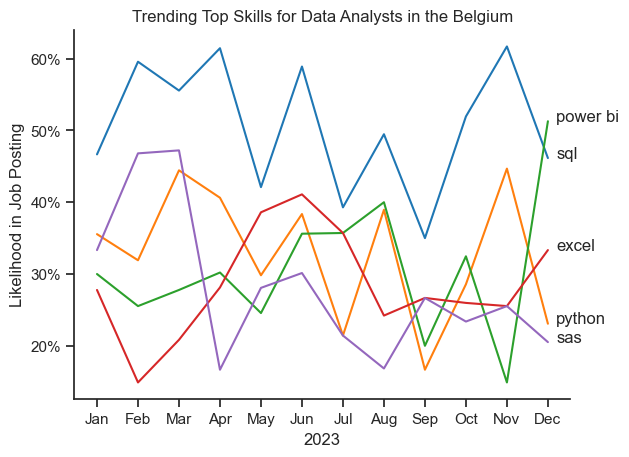

In [51]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in the Belgium')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter())

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])